# Librerias

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PolynomialFeatures
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)





from xgboost import XGBRegressor
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [2]:
data = pd.read_pickle('../Data/group_data.pkl')
data

,CV Co-evaluacion,Promedio Co-evaluacion,Desv. Estándar Co-evaluacion,Min Co-evaluacion,Indice Cohesion Grupal,diversidad_shannon,dominancia_equipo,cantidad_perfiles_unicos,balance_equipo
0,0.000000,1.000000,0.000000,1.000,1.000000,1.153742,0.571429,4,0.814423
1,0.086520,1.000000,0.086520,0.860,0.756759,1.320888,0.375000,4,0.911612
2,0.000000,1.000000,0.000000,1.000,1.000000,1.011404,0.500000,3,0.863917
3,0.102774,1.000143,0.102789,0.768,0.711123,1.277034,0.428571,4,0.881549
4,0.000000,1.000000,0.000000,1.000,1.000000,0.955700,0.571429,3,0.821826
...,...,...,...,...,...,...,...,...,...
72,0.120277,1.000000,0.120277,0.770,0.661854,1.153742,0.571429,4,0.814423
73,0.182029,1.026000,0.186762,0.710,0.487289,1.332179,0.400000,4,0.913397
74,0.240832,1.000000,0.240832,0.480,0.322929,1.351784,0.285714,4,0.938141
75,0.035271,1.001429,0.035322,0.940,0.901984,0.955700,0.571429,3,0.821826


In [12]:
input_variables = ['diversidad_shannon', 'dominancia_equipo', 'cantidad_perfiles_unicos', 'balance_equipo']
output_variables = ['CV Co-evaluacion', 'Promedio Co-evaluacion', 'Desv. Estándar Co-evaluacion', 
                    'Min Co-evaluacion', 'Indice Cohesion Grupal']

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def get_models_and_grids():
    models = {
        'LinearRegression': (LinearRegression(), None),
        'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}),
        'Lasso': (Lasso(max_iter=5000), {'alpha': [0.001, 0.01, 0.1, 1]}),
        'ElasticNet': (ElasticNet(max_iter=5000), {'alpha': [0.001, 0.01, 0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]}),
        'DecisionTreeRegressor': (DecisionTreeRegressor(random_state=42), {'max_depth': [2,3,4,5,None], 'min_samples_split': [2,5,10]}),
        'RandomForestRegressor': (RandomForestRegressor(random_state=42), {'n_estimators': [50,100], 'max_depth': [3,5,None]}),
        'ExtraTreesRegressor': (ExtraTreesRegressor(random_state=42), {'n_estimators': [50,100], 'max_depth': [3,5,None]}),
        'GradientBoostingRegressor': (GradientBoostingRegressor(random_state=42), {'n_estimators': [50,100], 'learning_rate': [0.01,0.05,0.1], 'max_depth': [2,3]})
    }
    return models



def evaluate_multivariate_models(
    data,
    input_variables,
    output_variable,
    models
):
    """
    Evalúa todos los modelos utilizando múltiples variables de entrada
    y una única variable objetivo.
    """

    # ==========================
    # Variables
    # ==========================
    X = data[input_variables]

    y = data[output_variable]

    # ==========================
    # Train/Test
    # ==========================
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.10,
        random_state=42
    )

    results = []

    for model_name, (model, param_grid) in models.items():

        print(f"\nEntrenando: {model_name}")

        # ---------------------------------
        # Grid Search
        # ---------------------------------
        # ---------------------------------
        # Grid Search
        # ---------------------------------
        if param_grid is not None:

            grid = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=5,
                scoring='r2',
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            best_params = grid.best_params_

        else:

            best_model = model
            best_model.fit(X_train, y_train)

            best_params = None
        # ---------------------------------
        # Cross Validation
        # ---------------------------------
        cv_scores = cross_val_score(
            best_model,
            X_train,
            y_train,
            cv=5,
            scoring='r2'
        )

        # ---------------------------------
        # Predicciones
        # ---------------------------------
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        # =====================================================
        # Gráfico: Valores Reales vs Predichos
        # =====================================================

        fig, ax = plt.subplots(figsize=(7, 6))

        ax.scatter(
            y_train,
            y_train_pred,
            alpha=0.7,
            label='Train'
        )

        ax.scatter(
            y_test,
            y_test_pred,
            alpha=0.9,
            label='Test'
        )

        # Línea identidad (Predicción perfecta)
        min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
        max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            linewidth=2,
            label='Predicción perfecta'
        )

        ax.set_title(f'{model_name}\nReal vs Predicho')
        ax.set_xlabel('Valor Real')
        ax.set_ylabel('Valor Predicho')
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ---------------------------------
        # Métricas
        # ---------------------------------

        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

        results.append({

            "Inputs": ", ".join(input_variables),

            "Output": output_variable,

            "Model": model_name,

            "Best Parameters": best_params,

            "CV Mean R2": cv_scores.mean(),

            "CV Std R2": cv_scores.std(),

            "Train R2": r2_score(y_train, y_train_pred),

            "Train RMSE": train_rmse,

            "Train MAE": mean_absolute_error(y_train, y_train_pred),

            "Test R2": r2_score(y_test, y_test_pred),

            "Test RMSE": test_rmse,

            "Test MAE": mean_absolute_error(y_test, y_test_pred)

        })
    


    results_df = pd.DataFrame(results)

    return results_df


Entrenando: LinearRegression


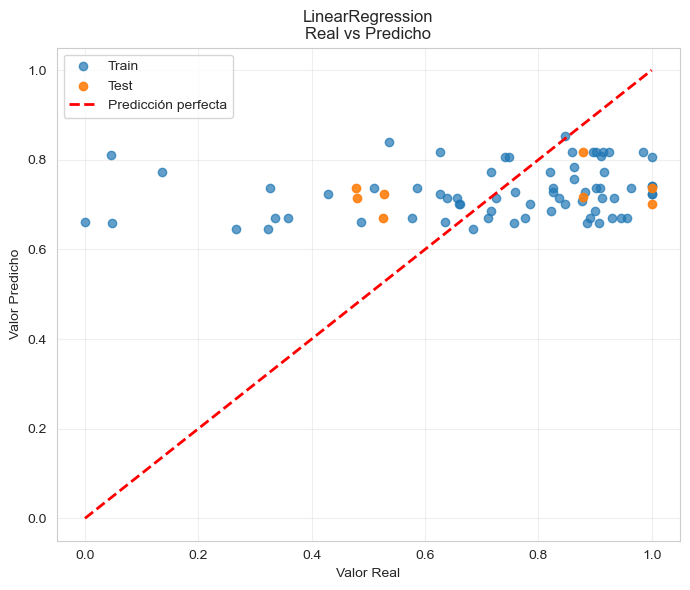


Entrenando: Ridge


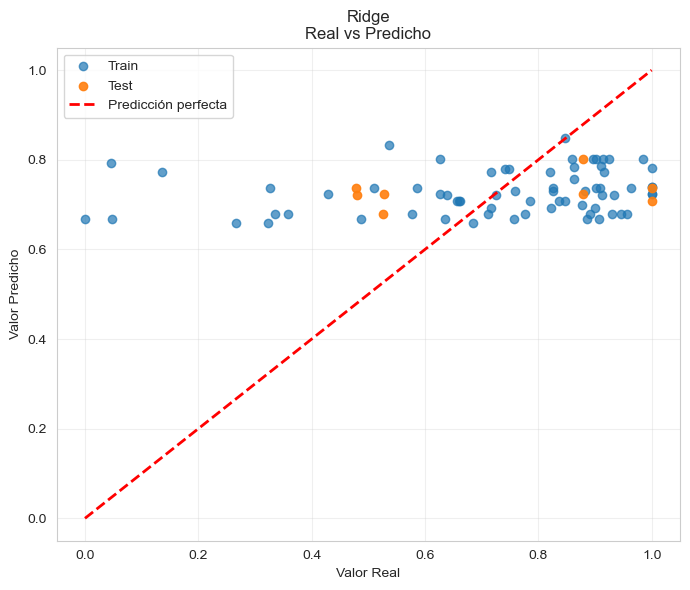


Entrenando: Lasso


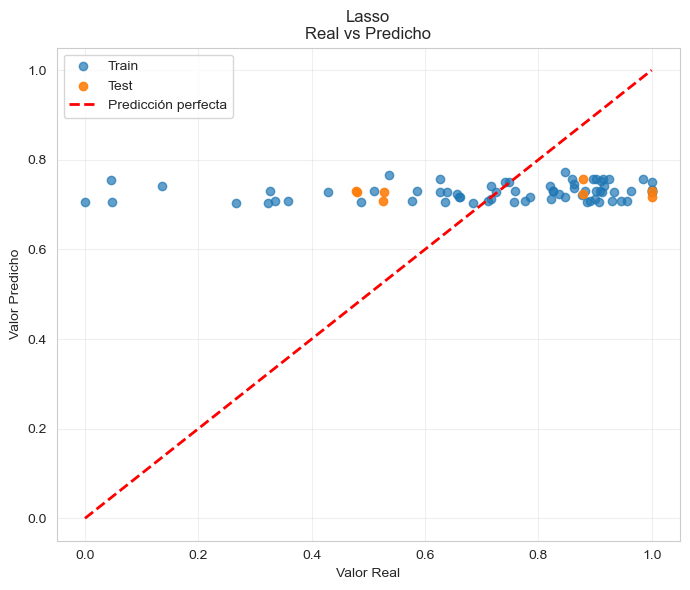


Entrenando: ElasticNet


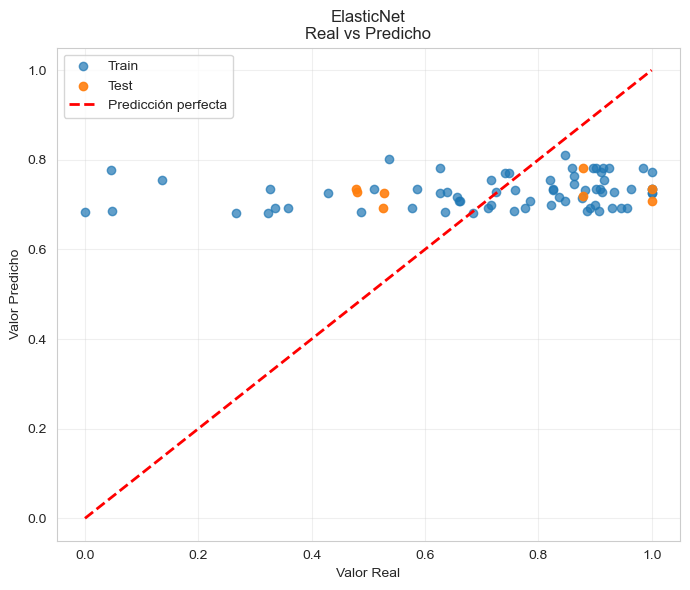


Entrenando: DecisionTreeRegressor


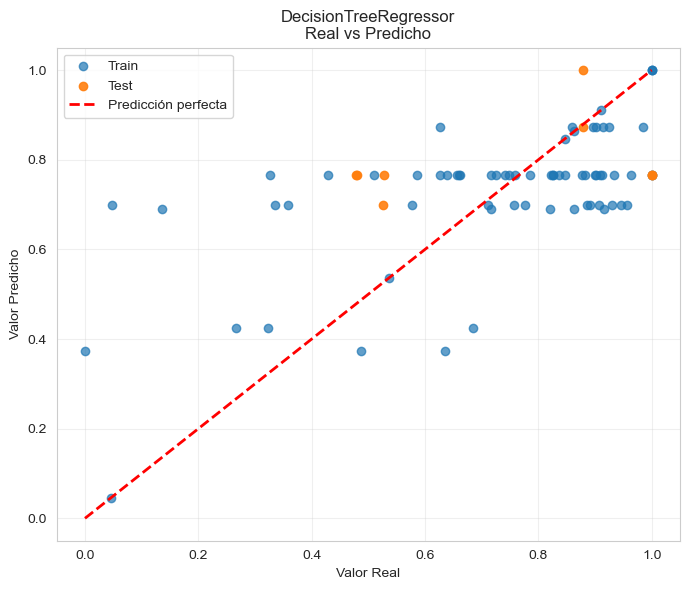


Entrenando: RandomForestRegressor


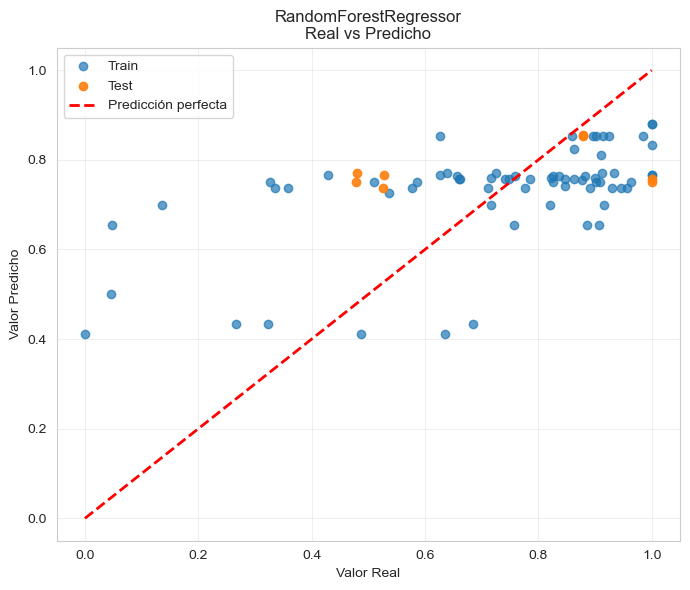


Entrenando: ExtraTreesRegressor


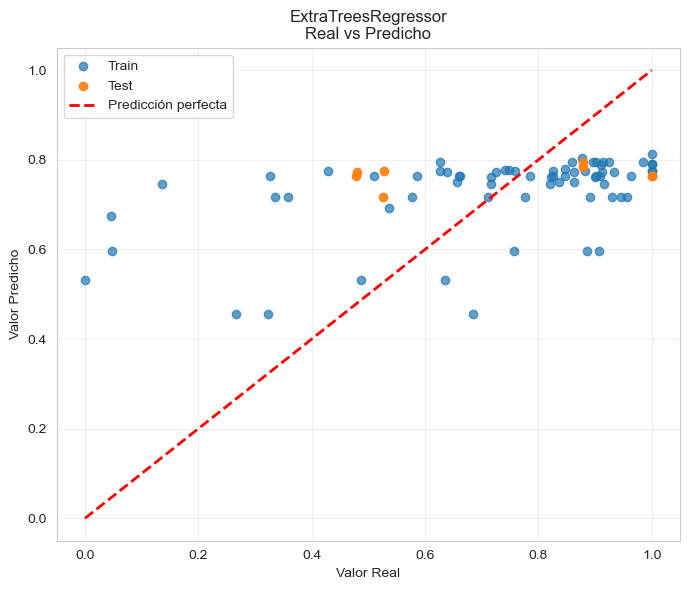


Entrenando: GradientBoostingRegressor


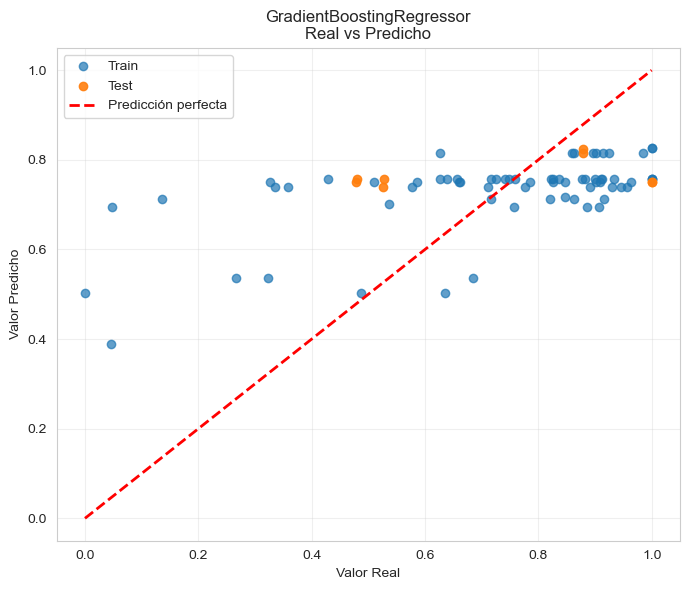

,Inputs,Output,Model,Best Parameters,CV Mean R2,CV Std R2,Train R2,Train RMSE,Train MAE,Test R2,Test RMSE,Test MAE
0,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,LinearRegression,None,-0.451009,0.722890,0.052591,0.241164,0.185199,0.070194,0.215170,0.202518
1,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,Ridge,{'alpha': 1},-0.336640,0.701662,0.050894,0.241380,0.185121,0.064337,0.215846,0.204896
4,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,DecisionTreeRegressor,"{'max_depth': 5, 'min_samples_split': 2}",-0.402148,0.563775,0.389836,0.193539,0.141312,0.055085,0.216911,0.197643
7,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,GradientBoostingRegressor,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-0.266204,0.550548,0.291333,0.208576,0.164702,0.043615,0.218223,0.201273
5,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,RandomForestRegressor,"{'max_depth': 3, 'n_estimators': 50}",-0.288370,0.524629,0.320224,0.204281,0.160091,0.040471,0.218582,0.194237
3,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5}",-0.335467,0.697065,0.044537,0.242187,0.186408,0.032398,0.219499,0.210558
2,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,Lasso,{'alpha': 0.01},-0.352909,0.693035,0.028330,0.244233,0.188339,0.019541,0.220953,0.214266
6,"diversidad_shannon, dominancia_equipo, balance...",Indice Cohesion Grupal,ExtraTreesRegressor,"{'max_depth': 3, 'n_estimators': 100}",-0.334812,0.721751,0.227182,0.217813,0.170704,0.012377,0.221759,0.208696


In [13]:
models = get_models_and_grids()

input_variables = [
    'diversidad_shannon',
    'dominancia_equipo',
    'balance_equipo'
]

output_variable = 'Indice Cohesion Grupal'

results_df = evaluate_multivariate_models(
    data=data,
    input_variables=input_variables,
    output_variable=output_variable,
    models=models
)

results_df = results_df.sort_values(
    by='Test R2',
    ascending=False
)

results_df